In [1]:
import tqdm
import torch
import glob
import networkx as nx
import numpy as np
from collections import Counter, defaultdict
from pathlib import Path
import logging

# --- Visualization Functions (from your original code) ---
PALETTE = [
    "#ff6961", "#ffb480", "#f8f38d", "#42d6a4", "#08cad1", "#59adf6", "#9d94ff", "#c780e8",
    "#ff6b6b", "#f0c419", "#48bb78", "#38b2ac", "#4299e1", "#667eea", "#9f7aea", "#ed64a6",
    "#e53e3e", "#dd6b20", "#d69e2e", "#38a169", "#319795", "#3182ce", "#5a67d8", "#805ad5"
]

def create_dynamic_color_map(items: list) -> dict:
    """Creates a color map for a list of items, cycling through the palette."""
    return {item: PALETTE[i % len(PALETTE)] for i, item in enumerate(items)}


def visualize_dependency_graph(
        graph: nx.MultiDiGraph,
        output_folder: Path,
        doc_id: str,
        label: str
):
    """
    Creates an interactive Pyvis visualization of a dependency graph.
    Nodes are colored by their Part-of-Speech (POS) tag.
    Edges are colored by their dependency relation type.
    """
    # This function remains the same as in your original code.
    # ... (rest of the visualization function)

# --- Main Metrics Calculation ---

# Gather all graph file paths
dataset = "STF_HC"
train_paths = glob.glob(f"../data/datasets/{dataset}/train/interim/*.pt")
val_paths = glob.glob(f"../data/datasets/{dataset}/validation/interim/*.pt")
test_paths = glob.glob(f"../data/datasets/{dataset}/test/interim/*.pt")

all_paths = train_paths + val_paths + test_paths

# MODIFICATION 1: Use a nested defaultdict to store metrics per label
def create_metrics_dict():
    return {
        "num_graphs": 0,
        "node_counts": [],
        "edge_counts": [],
        "avg_in_degrees": [],
        "avg_out_degrees": [],
        "clustering_coeffs": [],
        "densities": [],
        "diameters": [],
        "avg_shortest_paths": [],
        "connected_components": [],
        "assortativities": [],
        "node_type_counter": Counter(),
        "edge_type_counter": Counter()
    }

metrics_by_label = defaultdict(create_metrics_dict)


for path in tqdm.tqdm(all_paths):
    doc_name, label, graph = torch.load(path)
    if not isinstance(graph, nx.MultiDiGraph):
        continue

    # MODIFICATION 2: Use the 'label' to select the correct metrics dictionary
    current_metrics = metrics_by_label[label]

    # --- Visualization call (optional, can be commented out for speed) ---
    # visualize_dependency_graph(
    #     graph=graph,
    #     output_folder=Path("../data/visualization"),
    #     doc_id=doc_name,
    #     label=label
    # )

    current_metrics["num_graphs"] += 1
    n_nodes = graph.number_of_nodes()
    n_edges = graph.number_of_edges()

    current_metrics["node_counts"].append(n_nodes)
    current_metrics["edge_counts"].append(n_edges)

    # === Node / edge types collection ===
    for _, data in graph.nodes(data=True):
        if "type" in data:
            current_metrics["node_type_counter"][data["type"]] += 1
    for _, _, data in graph.edges(data=True):
        if "type" in data:
            current_metrics["edge_type_counter"][data["type"]] += 1

    # === Degrees ===
    in_degrees = [deg for _, deg in graph.in_degree()]
    out_degrees = [deg for _, deg in graph.out_degree()]
    if in_degrees:
        current_metrics["avg_in_degrees"].append(np.mean(in_degrees))
    if out_degrees:
        current_metrics["avg_out_degrees"].append(np.mean(out_degrees))

    # === Clustering Coefficient ===
    undirected_simple = nx.Graph()
    for u, v in graph.edges():
        undirected_simple.add_edge(u, v)
    if undirected_simple.number_of_nodes() > 1:
        try:
            cc = nx.average_clustering(undirected_simple)
            current_metrics["clustering_coeffs"].append(cc)
        except Exception:
            pass

    # === Density ===
    current_metrics["densities"].append(nx.density(graph))
    current_metrics["connected_components"].append(nx.number_weakly_connected_components(graph))

    # === Shortest Path / Diameter ===
    simple_digraph = nx.DiGraph()
    simple_digraph.add_edges_from(graph.edges())
    try:
        if nx.is_weakly_connected(simple_digraph):
            sp = nx.average_shortest_path_length(simple_digraph)
            dia = nx.diameter(simple_digraph.to_undirected())
            current_metrics["avg_shortest_paths"].append(sp)
            current_metrics["diameters"].append(dia)
    except Exception:
        pass

    # === Assortativity ===
    try:
        assortativity = nx.degree_assortativity_coefficient(graph)
        if not np.isnan(assortativity):
            current_metrics["assortativities"].append(assortativity)
    except Exception:
        pass


# === Summary helpers (no changes needed here) ===
def summarize(values):
    if values:
        arr = np.array(values)
        return f"{np.median(arr):.4f3} ± {np.std(arr):.4f}"
    return "N/A"


def top_k(counter, k=10):
    if not counter:
        return "N/A"
    return dict(counter.most_common(k))

# MODIFICATION 3: Loop through each label to print its summary
for label, metrics in metrics_by_label.items():
    summary = {
        "total_graphs": metrics["num_graphs"],
        "nodes per graph (median ± std)": summarize(metrics["node_counts"]),
        "edges per graph (median ± std)": summarize(metrics["edge_counts"]),
        "avg in-degree (median ± std)": summarize(metrics["avg_in_degrees"]),
        "avg out-degree (median ± std)": summarize(metrics["avg_out_degrees"]),
        "avg clustering (median ± std)": summarize(metrics["clustering_coeffs"]),
        "density (median ± std)": summarize(metrics["densities"]),
        "diameter (median ± std)": summarize(metrics["diameters"]),
        "avg shortest path (median ± std)": summarize(metrics["avg_shortest_paths"]),
        "weakly connected components (median ± std)": summarize(metrics["connected_components"]),
        "assortativity (median ± std)": summarize(metrics["assortativities"]),
        "top node types": top_k(metrics["node_type_counter"]),
        "top edge types": top_k(metrics["edge_type_counter"]),
    }

    print(f"\n=== MultiDiGraph Metrics Summary for Label: {label} ===")
    for key, value in summary.items():
        print(f"{key}: {value}")

  0%|          | 0/1627 [00:00<?, ?it/s]/tmp/ipykernel_254570/200848127.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  doc_name, label, graph = torch.load(path)
100%|█


=== MultiDiGraph Metrics Summary for Label: Solto ===
total_graphs: 409
nodes per graph (median ± std): 264.0000 ± 146.5477
edges per graph (median ± std): 322.0000 ± 263.6253
avg in-degree (median ± std): 1.2445 ± 0.1745
avg out-degree (median ± std): 1.2445 ± 0.1745
avg clustering (median ± std): 0.0161 ± 0.0101
density (median ± std): 0.0046 ± 0.0020
diameter (median ± std): N/A
avg shortest path (median ± std): N/A
weakly connected components (median ± std): 4.0000 ± 2.7995
assortativity (median ± std): 0.1435 ± 0.1081
top node types: N/A
top edge types: N/A

=== MultiDiGraph Metrics Summary for Label: Preso ===
total_graphs: 1218
nodes per graph (median ± std): 261.0000 ± 136.1591
edges per graph (median ± std): 306.0000 ± 260.7856
avg in-degree (median ± std): 1.1979 ± 0.1819
avg out-degree (median ± std): 1.1979 ± 0.1819
avg clustering (median ± std): 0.0152 ± 0.0092
density (median ± std): 0.0046 ± 0.0016
diameter (median ± std): N/A
avg shortest path (median ± std): N/A
weakl

(array([230., 558., 460., 211.,  85.,  41.,  23.,  15.,   2.,   2.]),
 array([ 1. ,  2.9,  4.8,  6.7,  8.6, 10.5, 12.4, 14.3, 16.2, 18.1, 20. ]),
 <BarContainer object of 10 artists>)

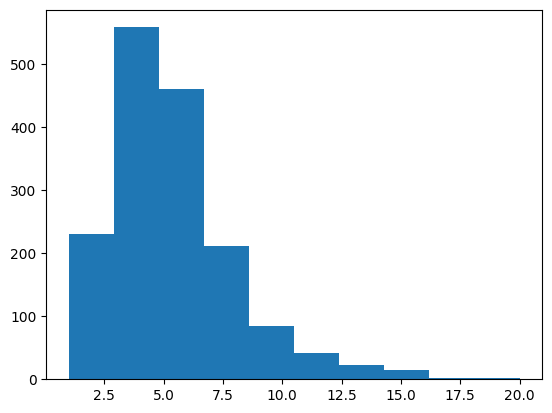

In [2]:
from matplotlib import pyplot as plt

plt.hist(metrics["connected_components"])